<a href="https://colab.research.google.com/github/HannahPeyambari/Analyzing-customer-satisfaction/blob/main/01_Olist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ______________________________________________________________


# 1. DATA UNDERSTANDING
# ______________________________________________________________



###### Load core tables to inspect structure before any cleaning or analysis.

In [1]:
import pandas as pd
try:
  orders = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/olist_orders_dataset.csv')
  customers = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/olist_customers_dataset.csv')
  order_items = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/olist_order_items_dataset.csv')
  payment = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/olist_order_payments_dataset.csv')
  reviews = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/olist_order_reviews_dataset.csv')
  products = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/olist_products_dataset.csv')
  sellers = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/olist_sellers_dataset.csv')
  geolocation = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/olist_geolocation_dataset.csv')
  translation = pd.read_csv('/content/drive/MyDrive/Olist_Dataset/product_category_name_translation.csv')

except Exception as e:
  print(e)


In [2]:
orders.info() # Check row count, column count, dtypes, and missing values.
orders.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


(99441, 8)

In [ ]:
orders_date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
orders[orders_date_cols] = orders[orders_date_cols].apply(pd.to_datetime)
orders[orders_date_cols].info()

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
customers.info() # Check row count, column count, dtypes, and missing values.
customers.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


(99441, 5)

In [6]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [7]:
order_items.info() # Check row count, column count, dtypes, and missing values.
order_items.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


(112650, 7)

In [8]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [9]:
order_items['shipping_limit_date'] = order_items['shipping_limit_date'].apply(pd.to_datetime)
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [10]:
reviews.info() # Check row count, column count, dtypes, and missing values.
reviews.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


(99224, 7)

In [11]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [12]:
reviews['review_score'].unique()

array([4, 5, 1, 3, 2])

In [13]:
# Inspect the distribution of review scores to understand customer satisfaction normalize=True converts raw counts into proportions (0-1), making it easier to compare distributions regardless of sample size.
review_score_distribution = reviews['review_score'].value_counts(normalize=True) * 100
review_score_distribution

,proportion
review_score,
5,57.776344
4,19.291704
1,11.513344
3,8.242965
2,3.175643


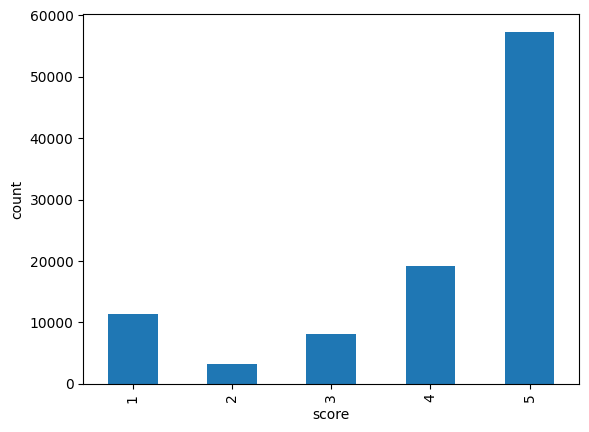

In [14]:
# Visualize the distribution to spot patterns not obvious from raw numbers.

import matplotlib.pyplot as plt

reviews['review_score'].value_counts().sort_index().plot(kind='bar')
plt.title('Score distribution')
plt.xlabel('score')
plt.ylabel('count')
plt.show()

# ______________________________________________________________
# 2. BUSINESS UNDERSTANDING
# ______________________________________________________________

######  Hypothesis: Late deliveries (actual delivery date later than the estimated delivery date) are associated with lower review scores. This hypothesis is testable because both delivery dates and review scores exist in the dataset.

In [15]:
# Merge orders with reviews to bring delivery dates and review scores into a single table. Using an inner join because we can only analyze orders that have both order data and a review score.
merged_orders_reviews = pd.merge(orders, reviews, on='order_id', how='inner')

In [16]:
merged_orders_reviews.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [17]:
merged_orders_reviews.shape

(99224, 14)

In [19]:
merged_orders_reviews['delivery_delay'] = (merged_orders_reviews['order_delivered_customer_date'] - merged_orders_reviews['order_estimated_delivery_date']).dt.days

In [20]:
merged_orders_reviews['delivery_delay'].describe()

,delivery_delay
count,96359.000000
mean,-11.917797
std,10.114024
min,-147.000000
25%,-17.000000
50%,-12.000000
75%,-7.000000
max,188.000000


In [21]:
late_delivery = merged_orders_reviews[merged_orders_reviews['delivery_delay'] > 0]
percentage_late = len(late_delivery) / len(merged_orders_reviews) * 100
print(f'Percentage of late delivery: {percentage_late:.2f}%')

Percentage of late delivery: 6.46%


In [24]:
merged_orders_reviews['is_late'] = merged_orders_reviews['delivery_delay'] > 0
merged_orders_reviews.groupby('is_late')['review_score'].mean()

,review_score
is_late,
False,4.211789
True,2.271139


In [25]:
merged_orders_reviews['order_status'].value_counts()

,count
order_status,
delivered,96361
shipped,1043
canceled,609
unavailable,597
invoiced,313
processing,296
created,3
approved,2


In [26]:
merged_orders_reviews['order_status'].value_counts(normalize = True) * 100

,proportion
order_status,
delivered,97.114609
shipped,1.051157
canceled,0.613763
unavailable,0.601669
invoiced,0.315448
processing,0.298315
created,0.003023
approved,0.002016
